In [63]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [64]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kahau\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [65]:
os.listdir(path)

['amz_uk_price_prediction_dataset.csv']

In [66]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "amz_uk_price_prediction_dataset.csv"
)

df = pd.read_csv(file_path)

df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [67]:
df.shape
df.head()
df.info()
df.isna().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [68]:

df.isnull().sum()


uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [69]:
df = df[df.columns[df.isnull().mean() < 0.8]]


potential_categorical = (
    df.select_dtypes("number")
      .loc[:, df.select_dtypes("number").nunique() < 20]
)

df_categorical = pd.concat(
    [df.select_dtypes("object"), potential_categorical],
    axis=1
)

df_numerical = (
    df.select_dtypes("number")
      .drop(columns=potential_categorical.columns))

In [70]:
df["isBestSeller"].dtype

dtype('bool')

In [71]:
bestseller_crosstab = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

bestseller_crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [72]:
bestseller_proportions = pd.crosstab(
    df["category"],
    df["isBestSeller"],
    normalize="index"
)

bestseller_proportions.head()

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811


In [73]:
bestseller_proportions[True].sort_values(
    ascending=False
).head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: True, dtype: float64

In [74]:
bestseller_summary = pd.DataFrame({
    "product_count": df.groupby("category").size(),
    "bestseller_proportion": bestseller_proportions[True]
})

bestseller_summary.sort_values(
    "bestseller_proportion",
    ascending=False
).head(10)

,product_count,bestseller_proportion
category,,
Grocery,9564,0.058135
Smart Home Security & Lighting,104,0.057692
Health & Personal Care,9569,0.057686
Mobile Phone Accessories,259,0.042471
Power & Hand Tools,8659,0.035339
"Billiard, Snooker & Pool",249,0.032129
Pet Supplies,9437,0.030200
Home Brewing & Wine Making,246,0.028455
Wind Instruments,250,0.028000


In [75]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [76]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [77]:
from scipy.stats import chi2_contingency

chi2, p_value, degrees_freedom, expected = chi2_contingency(
    bestseller_crosstab
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", degrees_freedom)

Chi-square statistic: 36540.20270061387
P-value: 0.0
Degrees of freedom: 295


In [78]:
from scipy.stats.contingency import association

cramers_v = association(
    bestseller_crosstab,
    method="cramer"
)

cramers_v

0.1222829439760564

The chi-square test produced a p-value of 0, indicating that category and best-seller status are statistically associated. Cramér’s V was 0.122, suggesting that the strength of the relationship is weak.

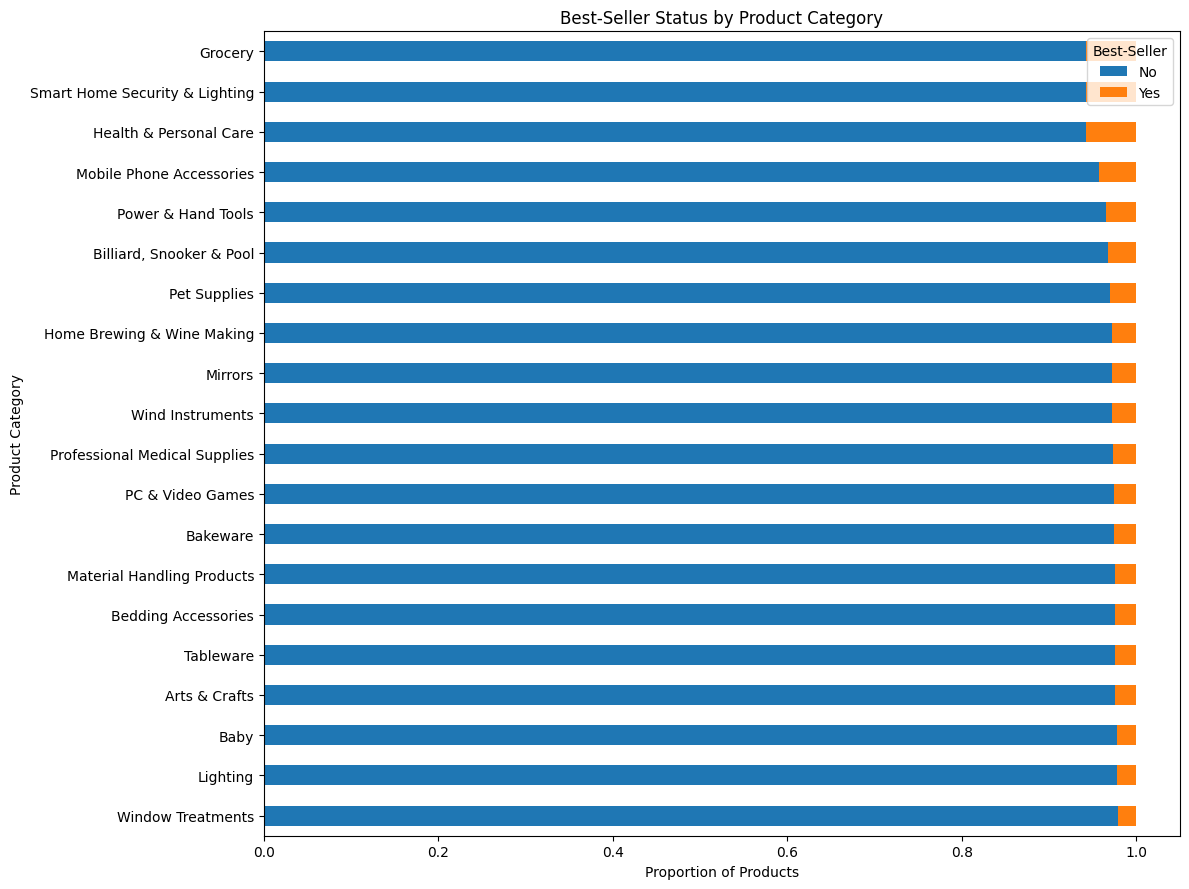

In [79]:
import matplotlib.pyplot as plt

# Count the number of products in each category
category_counts = df["category"].value_counts()

# Exclude very small categories
min_products = 100

eligible_categories = category_counts[
    category_counts >= min_products
].index

# Create proportional crosstab for eligible categories
category_proportions = pd.crosstab(
    df.loc[df["category"].isin(eligible_categories), "category"],
    df.loc[df["category"].isin(eligible_categories), "isBestSeller"],
    normalize="index"
)

# Select the 20 categories with the highest best-seller proportions
top_20_proportions = (
    category_proportions
    .sort_values(by=True, ascending=False)
    .head(20)
    .sort_values(by=True)
)

# Create horizontal stacked chart
ax = top_20_proportions.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 9)
)

ax.set_title("Best-Seller Status by Product Category")
ax.set_xlabel("Proportion of Products")
ax.set_ylabel("Product Category")
ax.legend(
    title="Best-Seller",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()



In [80]:
# Calculate the first and third quartiles
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Calculate the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a new dataframe without price outliers
df_no_price_outliers = df[
    df["price"].between(lower_bound, upper_bound)
].copy()

In [81]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Original number of rows:", len(df))
print("Rows after removing outliers:", len(df_no_price_outliers))
print("Number of rows removed:", len(df) - len(df_no_price_outliers))

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001
Original number of rows: 2443651
Rows after removing outliers: 2115963
Number of rows removed: 327688


In [82]:
top_20_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(20)
    .index
)

top_20_df = df_no_price_outliers[
    df_no_price_outliers["category"].isin(top_20_categories)
]

In [83]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

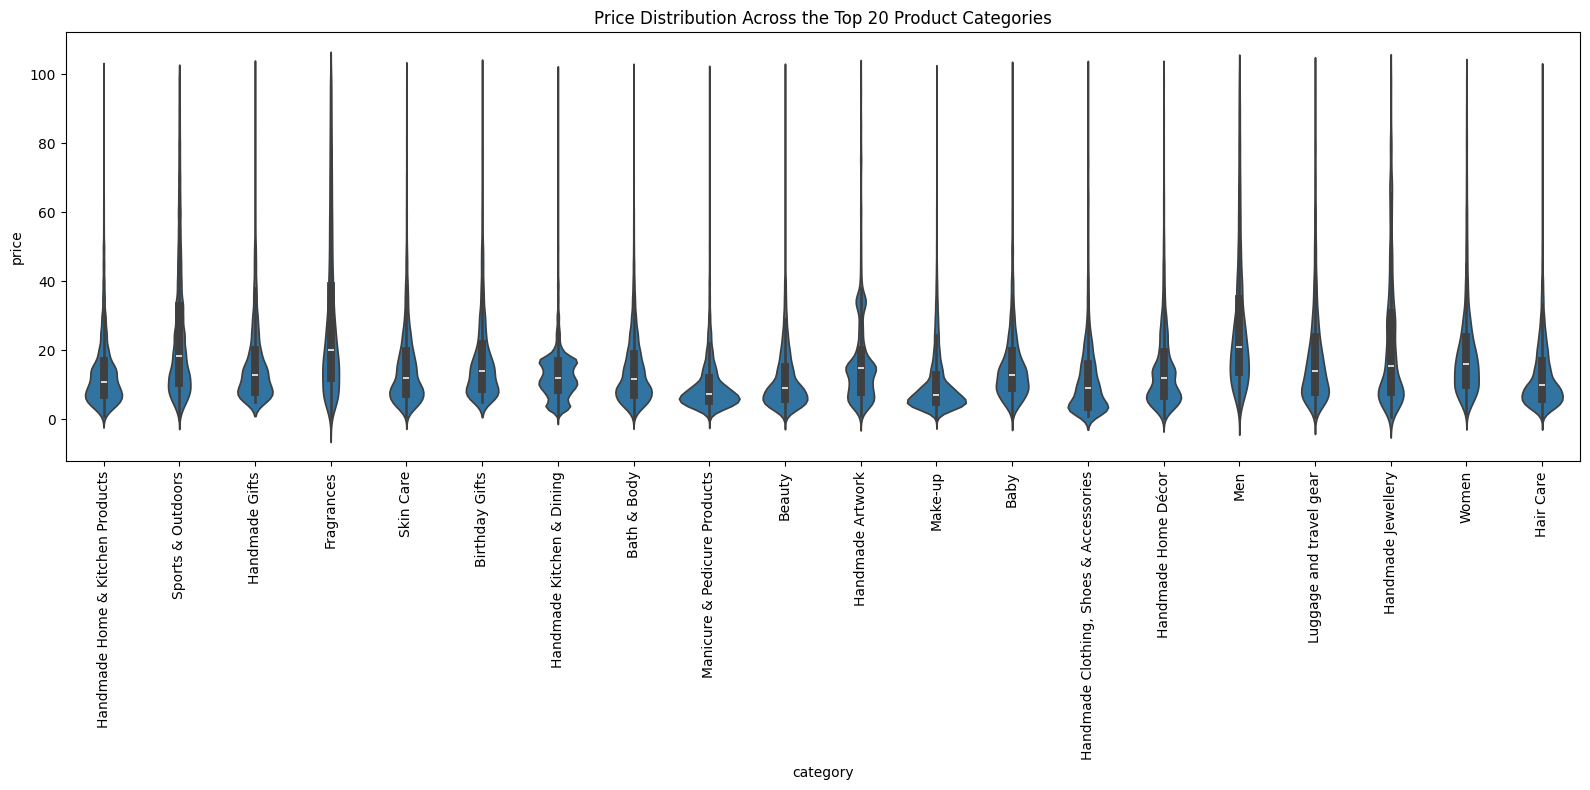

In [85]:
plt.figure(figsize=(16, 8))

sns.violinplot(
    data=top_20_df,
    x="category",
    y="price"
)

plt.xticks(rotation=90)
plt.title("Price Distribution Across the Top 20 Product Categories")
plt.tight_layout()
plt.show()

In [86]:
category_median_prices = (
    df_no_price_outliers
    .groupby("category")["price"]
    .agg(["count", "median"])
    .sort_values(by="median", ascending=False)
)

category_median_prices.head(10)

,count,median
category,,
Desktop PCs,169,74.00
Boxing Shoes,3873,69.79
Tablets,4638,69.00
Graphics Cards,57,68.54
Motherboards,74,67.92
Made in Italy Handmade,1561,64.00
Digital Frames,310,63.90
Streaming Clients,1692,62.68
Golf Shoes,4493,62.39


### Median Price by Product Category

After removing price outliers and comparing all product categories, **Desktop PCs** had the highest median price at **£74.00**.

This category contained **169 products**, so the result is based on a smaller sample than some of the other high-priced categories. For comparison, **Boxing Shoes** had the second-highest median price at **£69.79** across **3,873 products**, while **Tablets** had a median price of **£69.00** across **4,638 products**.

Overall, Desktop PCs tend to have the highest typical price, but the larger product counts for Boxing Shoes and Tablets make their median estimates more representative of their categories.

In [87]:
category_average_prices = (
    df_no_price_outliers
    .groupby("category")["price"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

category_average_prices.head(10)

,count,mean
category,,
Motherboards,74,68.772432
Boxing Shoes,3873,67.417803
Desktop PCs,169,66.915562
Tablets,4638,66.552971
Graphics Cards,57,65.103509
Digital Frames,310,60.745129
Streaming Clients,1692,60.241803
Hockey Shoes,221,60.094796
Computer Cases,173,58.339884


### Average Price by Product Category

After removing price outliers and comparing all product categories, **Motherboards** had the highest average price at approximately **£68.77**.

This result is based on **74 products**, which is a relatively small category compared with others near the top. For example, **Boxing Shoes** had the second-highest average price at approximately **£67.42**, based on **3,873 products**.

Therefore, Motherboards command the highest average price, although the much larger sample size for Boxing Shoes makes its average more representative of the wider category.

In [88]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable



You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm

In [90]:
part3_df = (
    df_no_price_outliers[["price", "stars"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

part3_df.head()

,price,stars
0,21.99,4.7
1,23.99,4.7
2,21.99,4.7
3,31.99,4.7
4,17.99,4.6


In [91]:
print("Rows used:", len(part3_df))

Rows used: 2115963


In [92]:
correlation, p_value = pearsonr(
    part3_df["price"],
    part3_df["stars"]
)

print("Pearson correlation:", correlation)
print("P-value:", p_value)

Pearson correlation: -0.07767299878179273
P-value: 0.0


In [93]:
scatter_sample = part3_df.sample(
    n=min(20000, len(part3_df)),
    random_state=42
)

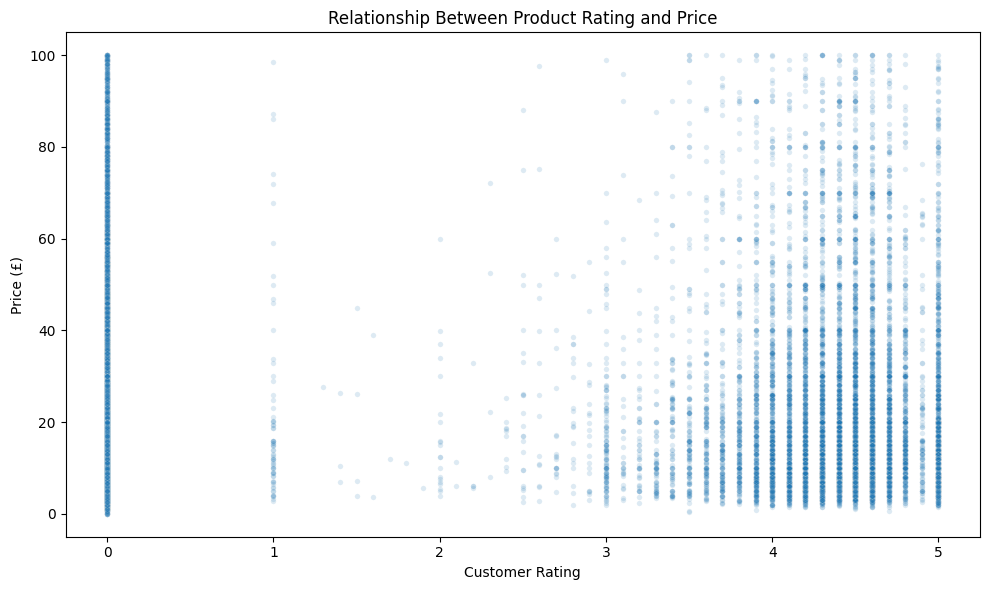

In [94]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="stars",
    y="price",
    alpha=0.15,
    s=15
)

plt.title("Relationship Between Product Rating and Price")
plt.xlabel("Customer Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

### Relationship Between Product Rating and Price

The scatter plot does not show a clear upward or downward trend between customer rating and product price. Products across nearly all rating levels appear throughout the price range, suggesting that higher-priced products do not consistently receive higher ratings.

The vertical bands occur because customer ratings use a limited set of repeated values. A particularly large concentration of products appears at a rating of 0, which may affect the overall correlation if these values represent products without customer ratings.

Overall, the visualization suggests that product price is not a strong predictor of customer rating. However, the Pearson correlation coefficient and p-value are needed to confirm the strength and statistical significance of this relationship.

In [95]:
numerical_df = df_no_price_outliers.select_dtypes(
    include="number"
)

numerical_df.columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='object')

In [96]:
correlation_matrix = numerical_df.corr(
    method="pearson"
)

correlation_matrix

,uid,stars,reviews,price,boughtInLastMonth
uid,1.000000,0.030288,0.020236,0.001717,0.017116
stars,0.030288,1.000000,0.083920,-0.077673,0.113994
reviews,0.020236,0.083920,1.000000,-0.008498,0.105624
price,0.001717,-0.077673,-0.008498,1.000000,-0.059051
boughtInLastMonth,0.017116,0.113994,0.105624,-0.059051,1.000000


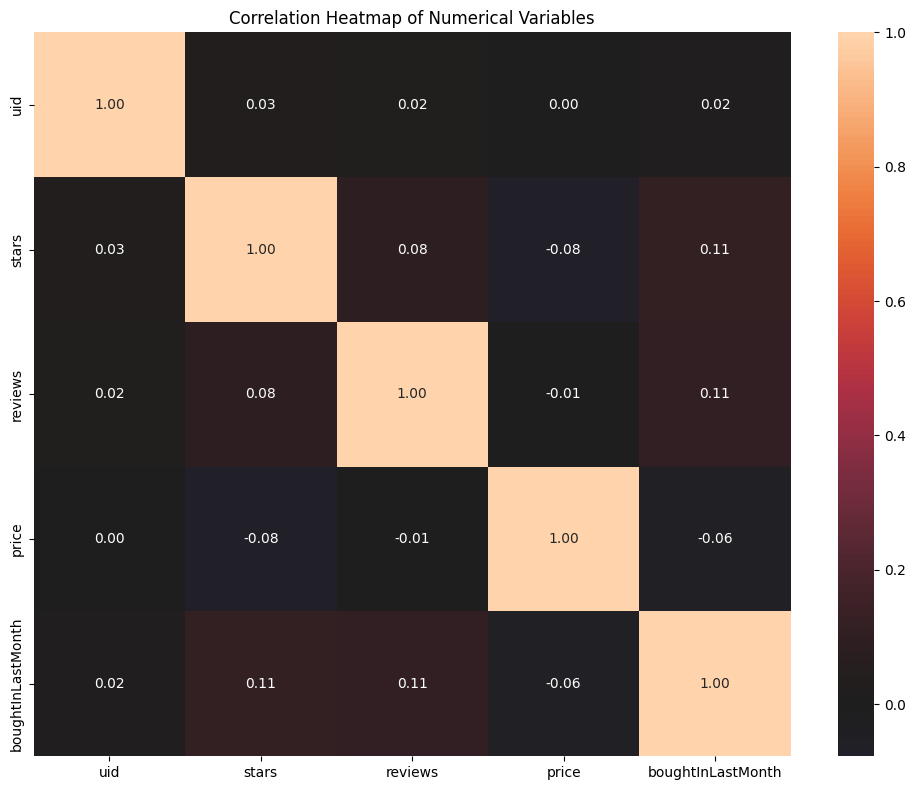

In [97]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Heatmap

The correlation heatmap shows that the numerical variables have generally weak linear relationships.

The correlation between **product price and customer rating** is **-0.08**, indicating a very weak negative relationship. This suggests that higher-priced products may receive slightly lower ratings, but the association is too small to be practically meaningful.

The strongest correlations in the heatmap are between **stars and products bought in the last month** and between **reviews and products bought in the last month**, both at approximately **0.11**. These are still weak positive relationships.

The correlation between **price and reviews** is approximately **-0.01**, indicating almost no linear relationship. Overall, product price does not appear to be strongly related to ratings, reviews, or recent purchase activity.

The `uid` variable is an identifier and therefore its correlations do not have meaningful analytical value.